In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [14]:

df = pd.read_csv('../data/insurance_data.csv', 
                 sep='|',          
                 low_memory=False)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (3168, 52)

Columns:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [15]:
# data overview
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   UnderwrittenCoverID       3168 non-null   int64  
 1   PolicyID                  3168 non-null   int64  
 2   TransactionMonth          3168 non-null   str    
 3   IsVATRegistered           3168 non-null   bool   
 4   Citizenship               3168 non-null   str    
 5   LegalType                 3168 non-null   str    
 6   Title                     3168 non-null   str    
 7   Language                  3168 non-null   str    
 8   Bank                      2592 non-null   str    
 9   AccountType               2592 non-null   str    
 10  MaritalStatus             3167 non-null   str    
 11  Gender                    3167 non-null   str    
 12  Country                   3167 non-null   str    
 13  Province                  3167 non-null   str    
 14  PostalCode         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,3168.0,NaN,NaN,NaN,103559.749684,61557.049479,2438.0,50187.0,120088.0,139085.0,277829.0
PolicyID,3168.0,NaN,NaN,NaN,8224.786616,5625.745205,283.0,1064.0,8672.0,11719.0,21252.0
TransactionMonth,3168,19,2015-06-01 00:00:00,356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IsVATRegistered,3168,2,False,2367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citizenship,3168,1,,3168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LegalType,3168,2,Individual,1741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,3168,3,Mr,1427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,3168,1,English,3168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bank,2592,5,First National Bank,1211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountType,2592,3,Current account,1948,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# missing value
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing Values (%):\n", missing)

Missing Values (%):
 CrossBorder                 100.00
NumberOfVehiclesInFleet     100.00
WrittenOff                   75.79
Rebuilt                      75.79
Converted                    75.79
CustomValueEstimate          62.34
NewVehicle                   23.17
Bank                         18.18
AccountType                  18.18
Country                       0.03
MaritalStatus                 0.03
Gender                        0.03
VehicleType                   0.03
mmcode                        0.03
ItemType                      0.03
SubCrestaZone                 0.03
MainCrestaZone                0.03
PostalCode                    0.03
Province                      0.03
RegistrationYear              0.03
NumberOfDoors                 0.03
bodytype                      0.03
kilowatts                     0.03
cubiccapacity                 0.03
TrackingDevice                0.03
make                          0.03
Model                         0.03
Cylinders                     0.03

In [17]:
# Core Insurance Metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['ClaimOccurred'] = (df['TotalClaims'] > 0).astype(int)

# Date conversion
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

In [18]:
# 1. Overall Loss Ratio
print("=== OVERALL PORTFOLIO ===")
print(f"Overall Loss Ratio: {df['LossRatio'].mean():.2%}")
print(f"Overall Average Margin: {df['Margin'].mean():.2f} Rand")

# Loss Ratio by Province
print("\nLoss Ratio by Province:")
print(df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False))

# Loss Ratio by Gender
print("\nLoss Ratio by Gender:")
print(df.groupby('Gender')['LossRatio'].mean())

# Loss Ratio by VehicleType
print("\nLoss Ratio by VehicleType:")
print(df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False))

=== OVERALL PORTFOLIO ===
Overall Loss Ratio: 19.82%
Overall Average Margin: 32.41 Rand

Loss Ratio by Province:
Province
Mpumalanga       0.307977
KwaZulu-Natal    0.230772
Gauteng          0.219014
Eastern Cape     0.000000
Limpopo          0.000000
North West       0.000000
Western Cape     0.000000
Name: LossRatio, dtype: float64

Loss Ratio by Gender:
Gender
Not specified    0.198184
Name: LossRatio, dtype: float64

Loss Ratio by VehicleType:
VehicleType
Passenger Vehicle    0.208242
Medium Commercial    0.132614
Name: LossRatio, dtype: float64


In [19]:
# 3. Temporal Trends
monthly = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
    'ClaimOccurred': 'mean',
    'LossRatio': 'mean'
}).round(3)

print("\nMonthly Trends:")
print(monthly)


Monthly Trends:
                  TotalPremium  TotalClaims  ClaimOccurred  LossRatio
TransactionMonth                                                     
2014-02               1653.292        0.000          0.000      0.000
2014-03               2593.392        0.000          0.000      0.000
2014-04               2829.049        0.000          0.000      0.000
2014-05               3251.898        0.000          0.000      0.000
2014-06               2829.049        0.000          0.000      0.000
2014-07               2932.105        0.000          0.000      0.000
2014-08               4755.202        0.000          0.000      0.000
2014-09               4574.134        0.000          0.000      0.000
2014-10               5968.198    28810.956          0.020      0.556
2014-11               6303.540        0.000          0.000      0.000
2014-12              11802.455        0.000          0.000      0.000
2015-01              13999.914    16715.000          0.005      0.181
201

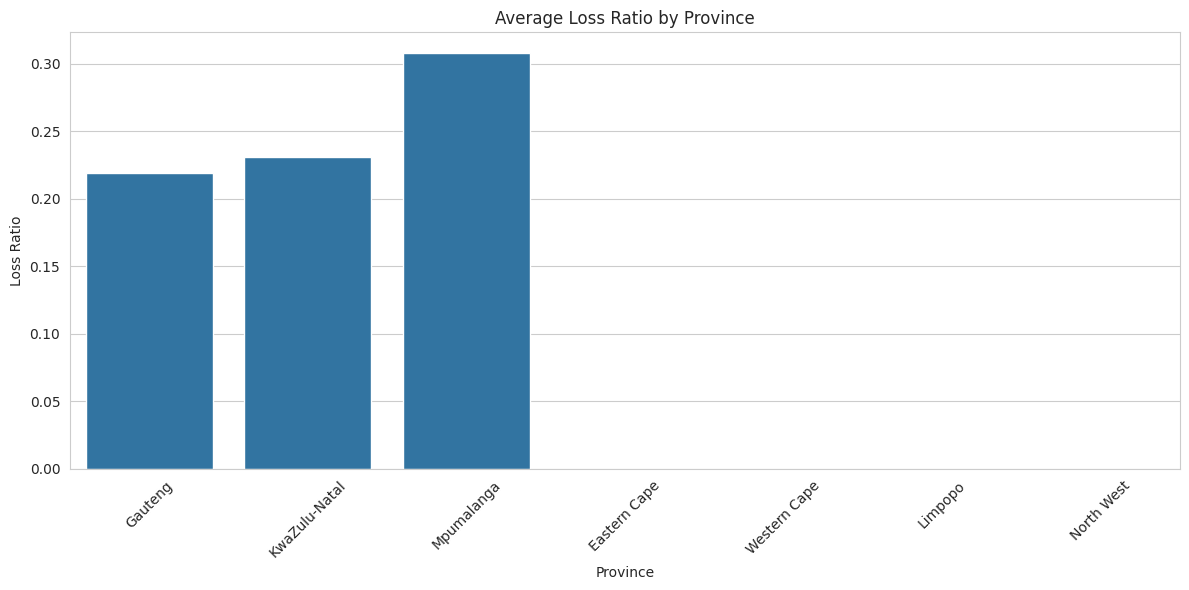

In [20]:
plt.figure()
sns.barplot(x='Province', y='LossRatio', data=df, estimator=np.mean, errorbar=None)
plt.title('Average Loss Ratio by Province')
plt.xticks(rotation=45)
plt.ylabel('Loss Ratio')
plt.tight_layout()
plt.show()

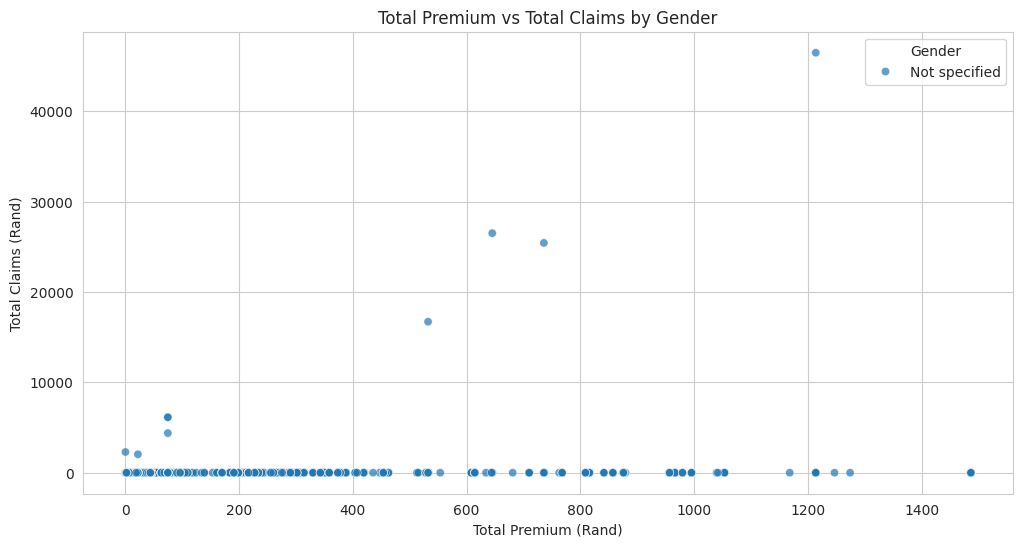

In [21]:
plt.figure()
sns.scatterplot(x='TotalPremium', y='TotalClaims', hue='Gender', data=df, alpha=0.7)
plt.title('Total Premium vs Total Claims by Gender')
plt.xlabel('Total Premium (Rand)')
plt.ylabel('Total Claims (Rand)')
plt.show()

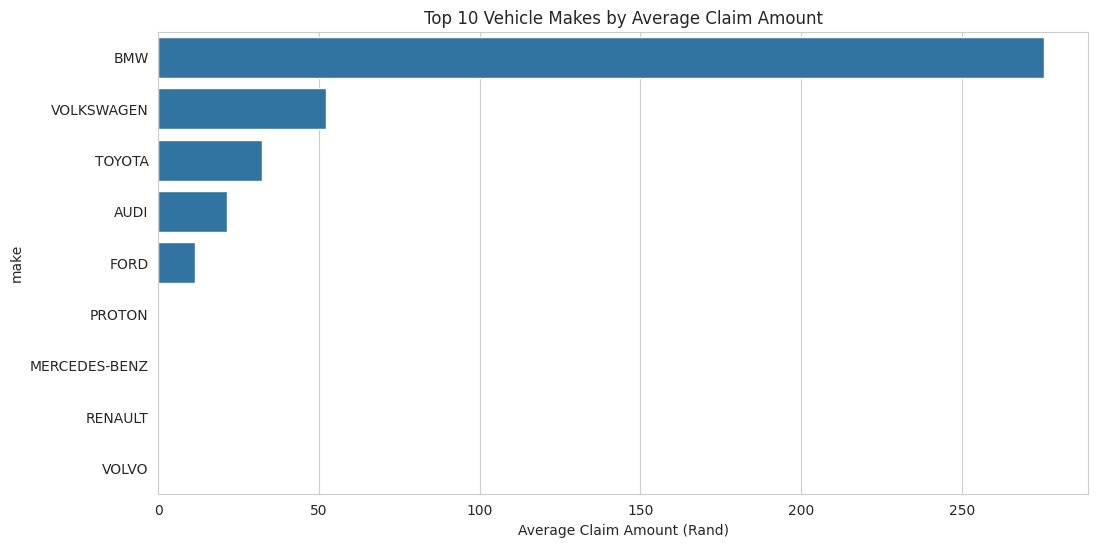

In [22]:
top_makes = df.groupby('make')['TotalClaims'].mean().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_makes.values, y=top_makes.index)
plt.title('Top 10 Vehicle Makes by Average Claim Amount')
plt.xlabel('Average Claim Amount (Rand)')
plt.show()

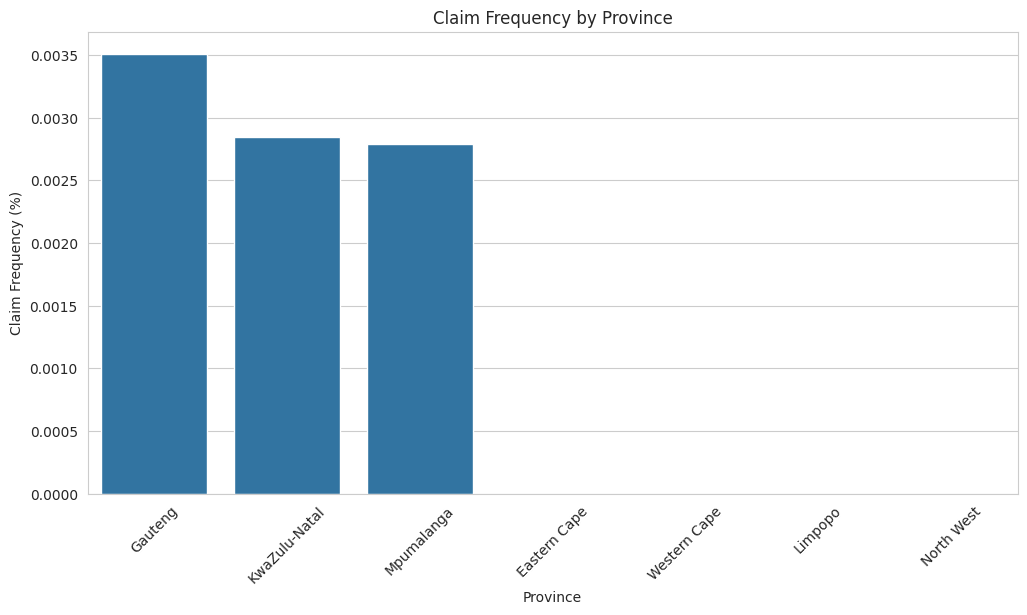

In [23]:
plt.figure()
sns.barplot(x='Province', y='ClaimOccurred', data=df, estimator=np.mean, errorbar=None)
plt.title('Claim Frequency by Province')
plt.xticks(rotation=45)
plt.ylabel('Claim Frequency (%)')
plt.show()

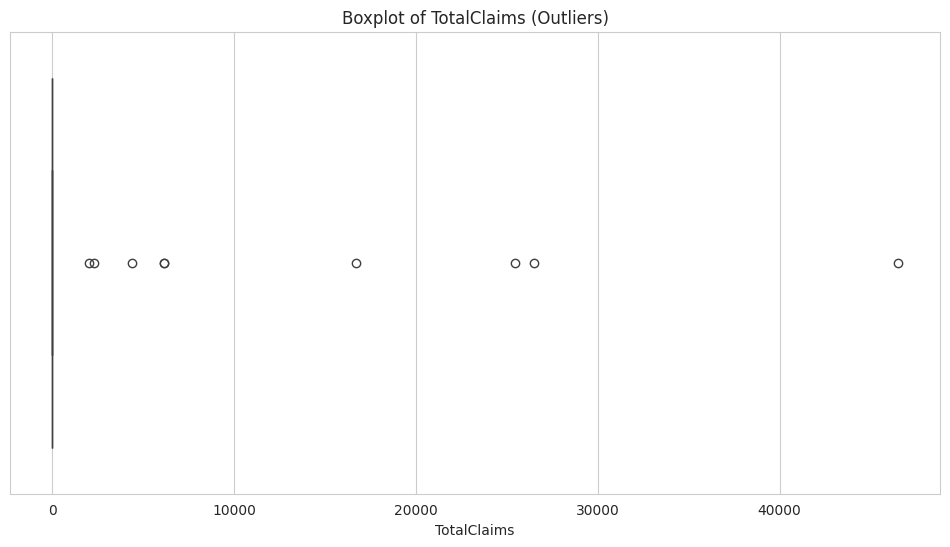

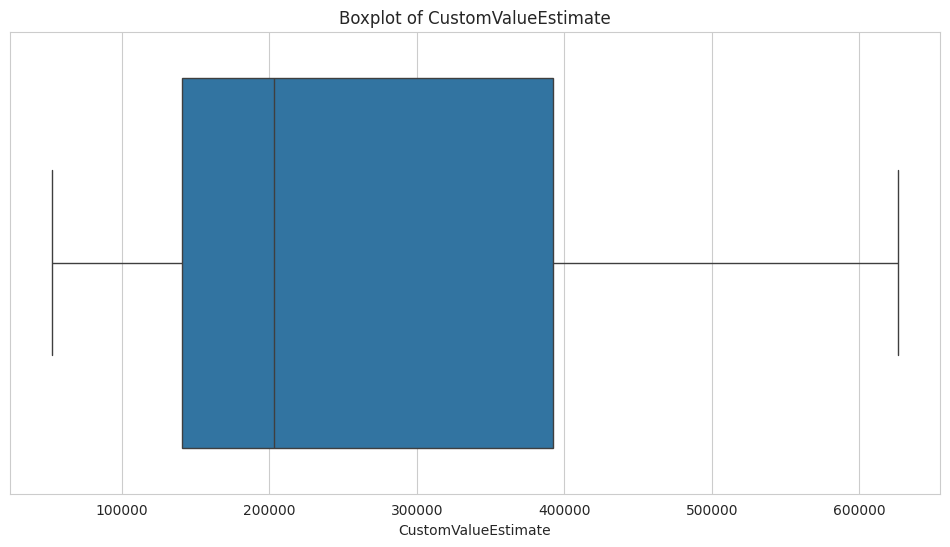

In [24]:
plt.figure()
sns.boxplot(x=df['TotalClaims'])
plt.title('Boxplot of TotalClaims (Outliers)')
plt.show()

plt.figure()
sns.boxplot(x=df['CustomValueEstimate'])
plt.title('Boxplot of CustomValueEstimate')
plt.show()